<a href="https://colab.research.google.com/github/pedromurcia1232/week_7/blob/main/Actividad_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


##Actividad 7



### Preparación de Entorno y Datos
Importamos las librerías necesarias (NumPy para operaciones de matriz y Matplotlib para visualización) y generamos una imagen sintética (matriz) para procesar.

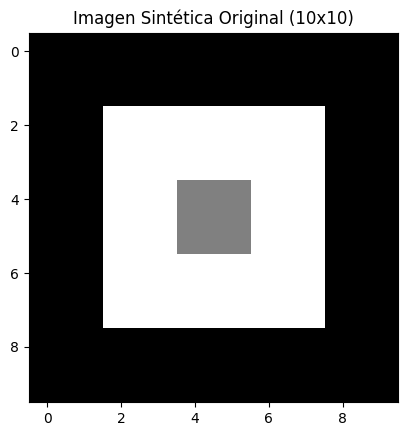

In [ ]:
import numpy as np # Importamos NumPy para el manejo de matrices y arreglos numéricos
import matplotlib.pyplot as plt # Importamos Matplotlib para la generación de gráficos
import time # Importamos time para posibles mediciones de rendimiento

# Generar una imagen sintética de 10x10 con un patrón simple
image = np.zeros((10, 10)) # Creamos una matriz de 10x10 llena de ceros (color negro)
image[2:8, 2:8] = 1  # Dibujamos un cuadrado blanco (valor 1) en el centro
image[4:6, 4:6] = 0.5 # Dibujamos un cuadro gris (valor 0.5) dentro del blanco para añadir complejidad

# Definir un kernel de detección de bordes (Sobel vertical)
kernel = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]]) # El kernel Sobel vertical resalta cambios de intensidad de izquierda a derecha

plt.imshow(image, cmap='gray') # Mostramos la matriz como una imagen en escala de grises
plt.title("Imagen Sintética Original (10x10)") # Añadimos un título al gráfico
plt.show() # Desplegamos la visualización

### Arquitectura Base de la Operación
Definimos la lógica de la convolución manual. Esta función actúa como nuestra 'arquitectura', permitiendo modificar parámetros de entrada como el tamaño del kernel, padding y stride.

In [ ]:
def convolve2d(image, kernel, padding=0, stride=1):
    # Aplicar padding si es necesario
    if padding > 0:
        # Añadimos bordes de ceros alrededor de la imagen original
        image_padded = np.pad(image, pad_width=padding, mode='constant', constant_values=0)
    else:
        # Si no hay padding, usamos la imagen tal cual
        image_padded = image

    (iH, iW) = image_padded.shape # Obtenemos las dimensiones de la imagen (con padding)
    (kH, kW) = kernel.shape # Obtenemos las dimensiones del kernel

    # Calcular dimensiones de salida usando la fórmula estándar de convolución
    out_h = (iH - kH) // stride + 1 # Altura de salida
    out_w = (iW - kW) // stride + 1 # Anchura de salida

    output = np.zeros((out_h, out_w)) # Inicializamos la matriz de salida con ceros

    # Registro de "activación" o respuesta para análisis pedagógico
    history = []

    # Operación de convolución (recorrido de la ventana)
    for y in range(0, out_h):
        for x in range(0, out_w):
            # Extraer región de interés (ROI) según la posición actual y el stride
            roi = image_padded[y*stride : y*stride + kH, x*stride : x*stride + kW]
            # Multiplicación elemento a elemento y suma de resultados
            k = (roi * kernel).sum()
            output[y, x] = k # Guardamos el resultado en el mapa de características
            # Guardamos el valor absoluto para graficar la magnitud de la respuesta
            history.append(np.abs(k))

    return output, history # Retornamos el mapa de características y el historial de valores

### Entrenar Modelo (Ejecución de Experimentos)
Realizamos tres configuraciones comparables: Base, con Padding y con Stride.

In [ ]:
print("Ejecutando Configuración 1: Base (Pad=0, Stride=1)")
# Ejecutamos la convolución estándar sin relleno y paso simple
res_base, hist_base = convolve2d(image, kernel, padding=0, stride=1)

print("\nEjecutando Configuración 2: Con Padding (Pad=1, Stride=1)")
# Ejecutamos con relleno de 1 píxel para intentar mantener el tamaño original
res_pad, hist_pad = convolve2d(image, kernel, padding=1, stride=1)

print("\nEjecutando Configuración 3: Con Stride (Pad=0, Stride=2)")
# Ejecutamos con saltos de 2 píxeles para reducir la dimensionalidad
res_stride, hist_stride = convolve2d(image, kernel, padding=0, stride=2)

print("\nProceso completado.") # Mensaje final de ejecución

Ejecutando Configuración 1: Base (Pad=0, Stride=1)

Ejecutando Configuración 2: Con Padding (Pad=1, Stride=1)

Ejecutando Configuración 3: Con Stride (Pad=0, Stride=2)

Proceso completado.


### Visualizar el Comportamiento
Comparamos la magnitud de los valores obtenidos (nuestro equivalente a curvas de activación/pérdida) durante la operación.

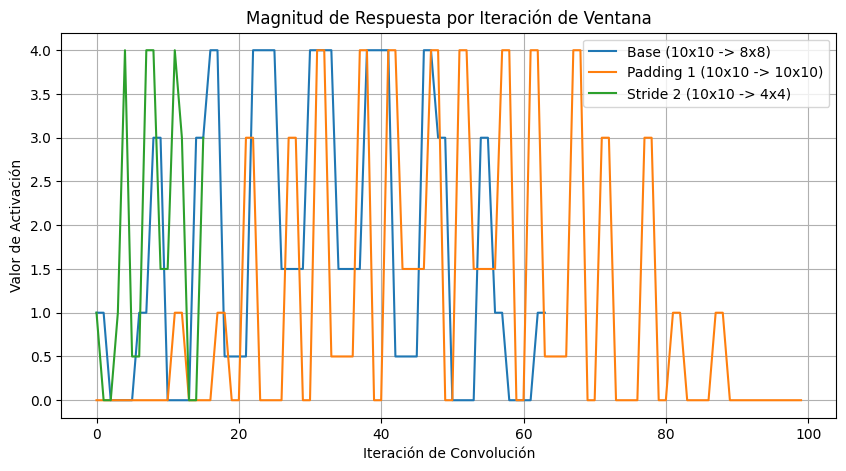

In [ ]:
plt.figure(figsize=(10, 5)) # Definimos el tamaño del lienzo del gráfico
plt.plot(hist_base, label='Base (10x10 -> 8x8)') # Graficamos los valores de la configuración base
plt.plot(hist_pad, label='Padding 1 (10x10 -> 10x10)') # Graficamos los valores con padding
plt.plot(hist_stride, label='Stride 2 (10x10 -> 4x4)') # Graficamos los valores con stride
plt.title("Magnitud de Respuesta por Iteración de Ventana") # Título del gráfico
plt.xlabel("Iteración de Convolución") # Etiqueta del eje X
plt.ylabel("Valor de Activación") # Etiqueta del eje Y
plt.legend() # Mostramos la leyenda para identificar cada línea
plt.grid(True) # Activamos la cuadrícula de fondo
plt.show() # Mostramos el gráfico final

### ¿Qué vemos en las curvas de Magnitud?

Este gráfico representa la "fuerza" de la respuesta del kernel en cada paso de su recorrido. Imaginen que la línea es el latido del kernel mientras busca bordes:

*   **Los Picos (Altibajos):** Cada vez que la línea sube, significa que el kernel pasó por encima de un borde del cuadrado. Como nuestra imagen tiene un cuadrado central, vemos picos al inicio y al final de cada fila donde hay transiciones de color.
*   **Longitud de las líneas (Iteraciones):**
    *   La línea **naranja (Padding 1)** es la más larga (100 pasos). Esto es porque al añadir el marco de ceros, el kernel debe trabajar más para cubrir toda la superficie extendida.
    *   La línea **azul (Base)** tiene 64 pasos. Es más corta porque el kernel ignora los bordes y se queda solo con el 'corazón' de la imagen.
    *   La línea **verde (Stride 2)** es muy corta (solo 16 pasos). Al dar pasos dobles, termina su recorrido 4 veces más rápido, lo que demuestra visualmente la eficiencia (pero también la menor cantidad de datos procesados).

**¿Por qué es útil?** En redes neuronales reales, estas curvas nos ayudan a entender si una capa está detectando mucha información (mucha variabilidad y picos) o si está 'muerta' (líneas planas cerca de cero).

### Calcular Métricas y Presentar Resultados
Resumen técnico de las dimensiones resultantes y la preservación de información.

In [ ]:
def calculate_l2(matrix):
    # Calcula la norma euclidiana (L2) sumando los cuadrados y aplicando raíz cuadrada
    return np.sqrt(np.sum(np.square(matrix)))

# Creamos una lista de tuplas para iterar sobre los resultados obtenidos
configs = [
    ("Base", res_base),
    ("Padding 1", res_pad),
    ("Stride 2", res_stride)
]

# Imprimimos los encabezados de la tabla con formato de columnas
print(f"{'Configuración':<15} | {'Dimensiones':<12} | {'Norma L2':<10}")
print("-"*45) # Línea divisoria
for name, res in configs:
    l2 = calculate_l2(res) # Calculamos la norma L2 para cada matriz
    # Imprimimos el nombre, las dimensiones (shape) y el valor L2 con 4 decimales
    print(f"{name:<15} | {str(res.shape):<12} | {l2:.4f}")

Configuración   | Dimensiones  | Norma L2  
---------------------------------------------
Base            | (8, 8)       | 18.8680
Padding 1       | (10, 10)     | 18.8680
Stride 2        | (4, 4)       | 9.4340


### ¿Qué miden las Dimensiones y la Norma L2?

En nuestra tabla de resultados, usamos dos métricas clave para entender el impacto técnico de nuestras decisiones:

#### 1. Dimensiones (Tamaño de la Matriz)
Indican el **espacio físico** o la resolución del mapa de características resultante.
*   **Base (8x8):** Al no usar padding, perdemos 2 píxeles por lado debido al tamaño del kernel (3x3). La imagen se encoge.
*   **Padding (10x10):** El relleno permite que el kernel 'salga' de los bordes, manteniendo el tamaño original. Es vital para no perder resolución en redes profundas.
*   **Stride 2 (4x4):** Al dar pasos más grandes, reducimos drásticamente el mapa. Esto comprime la imagen, lo cual es excelente para ahorrar memoria y computación, pero perdemos detalle fino.

#### 2. Norma L2 (Magnitud de Respuesta)
Es una medida matemática que cuantifica la **magnitud total o 'energía'** de la respuesta detectada.
*   **En términos simples:** Es como medir cuánta información visual capturó el kernel en total.
*   **Comparación:** Observen que **Base** y **Padding** tienen la misma Norma L2 (18.8680) porque detectaron los mismos bordes. El **Stride 2** tiene la mitad (9.4340) porque al saltar píxeles, literalmente sumó menos activaciones, confirmando que descartamos parte de la señal original para ganar eficiencia.

### Gráficos de Resultados (Mapas de Características)
Visualización comparativa de cómo los parámetros afectan el resultado visual.

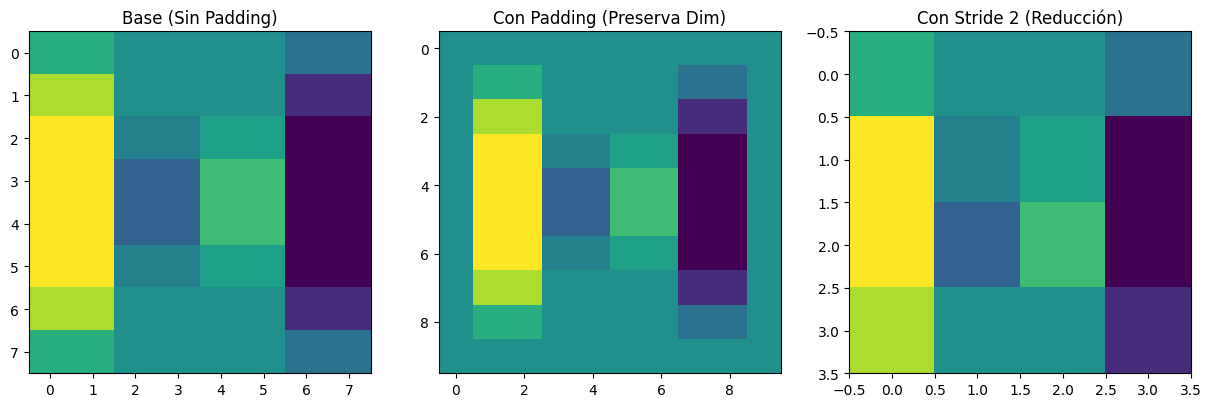

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5)) # Creamos una fila con 3 subgráficos

# Primer subgráfico: resultado sin padding
axes[0].imshow(res_base, cmap='viridis') # Usamos el mapa de colores viridis para resaltar contrastes
axes[0].set_title("Base (Sin Padding)") # Título específico

# Segundo subgráfico: resultado con padding
axes[1].imshow(res_pad, cmap='viridis') # Mostramos el mapa de características con padding
axes[1].set_title("Con Padding (Preserva Dim)") # Título específico

# Tercer subgráfico: resultado con stride
axes[2].imshow(res_stride, cmap='viridis') # Mostramos el mapa de características con reducción de tamaño
axes[2].set_title("Con Stride 2 (Reducción)") # Título específico

plt.show() # Desplegamos las tres imágenes para comparación visual

### ¿Cómo interpretar los Mapas de Características?

Al observar las imágenes anteriores (en escala de colores `viridis`), es fundamental entender qué nos están diciendo matemáticamente:

*   **El Color Amarillo/Brillante:** Representa valores positivos altos. En nuestro caso, indica una transición de **oscuro a claro** (un borde vertical izquierdo).
*   **El Color Púrpura/Oscuro:** Representa valores negativos bajos. Indica una transición de **claro a oscuro** (un borde vertical derecho).
*   **El Color Verde/Teal:** Representa valores cercanos a **cero**. Esto ocurre en las zonas planas donde no hay cambios (como el centro del cuadrado o el fondo), indicando que el kernel no detectó nada interesante ahí.

**Comparación de los Mapas:**
1.  **Mapa Base:** los bordes definidos. Es más pequeño que la imagen original porque el kernel no puede 'centrarse' en los píxeles de la orilla sin salirse de la matriz.
2.  **Mapa con Padding:** Es el único que conserva exactamente el marco de 10x10. los bordes están alineados con la posición original del cuadrado.
3.  **Mapa con Stride 2:** Se ve 'pixelado' o con menos resolución. Aunque todavía detecta dónde están los bordes, ha perdido la precisión de la forma original para ganar velocidad de procesamiento.

### Análisis y Conclusiones

**¿Qué representa la convolución?**
Imaginen que el **kernel** es una linterna o una lupa que busca patrones específicos (en este caso, bordes verticales). Al deslizar esta lupa sobre la imagen, la operación matemática de multiplicar y sumar nos indica qué tan fuerte es la presencia de ese patrón en cada zona. El resultado es un **Mapa de Características**, que resalta lo que el kernel 'encontró'.

**Entendiendo los Ajustes Técnicos:**

1.  **Padding (Relleno):**
    *   **El Problema:** Sin padding, los píxeles de los bordes solo se tocan una vez por el kernel, mientras que los del centro se procesan muchas veces. Esto causa que la imagen se 'encoja'.
    *   **La Solución:** Al rodear la imagen con ceros, le damos espacio al kernel para que empiece 'desde afuera'.
    *   **Resultado:** Mantenemos el tamaño original de la imagen (10x10) y no perdemos la información de las esquinas.

2.  **Stride (Zancada):**
    *   **El Concepto:** Es el tamaño del paso que da el kernel. Un stride de 1 es un paso de hormiga (píxel por píxel). Un stride de 2 es un salto.
    *   **El Efecto:** Al saltar píxeles, estamos ignorando parte de la información para obtener un resumen más pequeño.
    *   **Resultado:** Reducción drástica del tamaño (de 10x10 a 4x4). Es útil en redes neuronales profundas para reducir el costo computacional y 'comprimir' el conocimiento.

**Conclusión:**
Como observamos en nuestra tabla de métricas, el **Padding** es nuestro aliado cuando la resolución es crítica, mientras que el **Stride** es la herramienta ideal cuando necesitamos simplificar la complejidad de los datos sin perder la estructura esencial del objeto detectado.